In [2]:
# pip install folium
import pandas as pd, numpy as np

df = pd.read_csv(r"C:\Users\Girish\Downloads\india_regional_market_v2.csv")
print(df.shape, "| missing:", df.isna().sum().sum(), "| duplicates:", df.duplicated().sum())

df['City'] = df.City.str.strip().str.title()
df['State'] = df.State.str.strip().str.title()

print(df.groupby(['City', 'State']).size())             
print(df[['Latitude', 'Longitude']].describe().loc[['min', 'max']])  

(400, 11) | missing: 0 | duplicates: 0
City       State      
Ahmedabad  Gujarat        50
Bengaluru  Karnataka      32
Chennai    Tamil Nadu     47
Delhi      Delhi          56
Hyderabad  Telangana      42
Jaipur     Rajasthan      33
Kochi      Kerala         39
Kolkata    West Bengal    32
Mumbai     Maharashtra    28
Pune       Maharashtra    41
dtype: int64
     Latitude  Longitude
min   9.75541   72.39779
max  28.76743   88.53465


In [3]:
df['LeadsPerMonth'] = df.MonthlySearchDemand * df.LeadConversionRate
df['RevenuePotential'] = df.LeadsPerMonth * df.MedianAnnualIncomeINR   # proxy

city = df.groupby(['City', 'State']).agg(
    areas=('RegionID', 'count'),
    search_demand=('MonthlySearchDemand', 'sum'),
    leads=('LeadsPerMonth', 'sum'),
    revenue_potential_mn=('RevenuePotential', lambda s: s.sum() / 1e6),
    avg_competitors=('ExistingCompetitors', 'mean'),
    avg_conversion=('LeadConversionRate', 'mean'),
    avg_cac=('EstimatedAcquisitionCostINR', 'mean'),
    lat=('Latitude', 'mean'),
    lon=('Longitude', 'mean')).reset_index()

print(city.round(2).sort_values('leads', ascending=False).to_string())

        City        State  areas  search_demand    leads  revenue_potential_mn  avg_competitors  avg_conversion  avg_cac    lat    lon
0  Ahmedabad      Gujarat     50          52110  4231.07               2925.69             8.38            0.08   487.00  23.04  72.56
2    Chennai   Tamil Nadu     47          53771  4152.53               2909.62             7.94            0.08   411.68  13.09  80.27
4  Hyderabad    Telangana     42          48103  4083.18               2759.38             7.19            0.08   438.57  17.39  78.48
3      Delhi        Delhi     56          53007  3902.28               2681.93             8.02            0.07   486.23  28.61  77.20
9       Pune  Maharashtra     41          44574  3276.33               2181.79             7.93            0.07   479.20  18.53  73.84
6      Kochi       Kerala     39          39015  3182.03               2024.69             6.79            0.08   520.38   9.92  76.26
1  Bengaluru    Karnataka     32          33789  2967.3

In [4]:
mm = lambda s: (s - s.min()) / (s.max() - s.min())     # scale 0 to 1

df['Score'] = 100 * (0.35 * mm(df.MonthlySearchDemand)
                   + 0.25 * mm(df.LeadConversionRate)
                   + 0.20 * (1 - mm(df.ExistingCompetitors))
                   + 0.10 * (1 - mm(df.EstimatedAcquisitionCostINR))
                   + 0.10 * mm(df.MedianAnnualIncomeINR))

city = city.merge(df.groupby('City').Score.mean().rename('score').reset_index(), on='City')
city = city.sort_values('score', ascending=False).reset_index(drop=True)
print(city[['City', 'State', 'score', 'leads', 'avg_competitors', 'avg_cac']].round(1))

top_areas = df.sort_values('Score', ascending=False).head(10)
print(top_areas[['RegionID', 'City', 'MonthlySearchDemand', 'ExistingCompetitors', 'LeadConversionRate', 'Score']].round(2))

        City        State  score   leads  avg_competitors  avg_cac
0  Hyderabad    Telangana   54.2  4083.2              7.2    438.6
1     Mumbai  Maharashtra   54.1  2583.1              7.2    456.5
2    Chennai   Tamil Nadu   53.0  4152.5              7.9    411.7
3  Bengaluru    Karnataka   52.1  2967.4              7.7    476.3
4     Jaipur    Rajasthan   51.2  2606.4              7.7    446.8
5  Ahmedabad      Gujarat   50.8  4231.1              8.4    487.0
6      Kochi       Kerala   50.5  3182.0              6.8    520.4
7       Pune  Maharashtra   49.5  3276.3              7.9    479.2
8    Kolkata  West Bengal   49.2  2587.8              8.6    392.5
9      Delhi        Delhi   46.9  3902.3              8.0    486.2
     RegionID       City  MonthlySearchDemand  ExistingCompetitors  \
205  REG-0206      Kochi                 1787                    1   
372  REG-0373    Chennai                 1831                    5   
352  REG-0353    Kolkata                 1799        

In [12]:
import folium

m = folium.Map(location=[20.5, 79], zoom_start=5, tiles=None)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri', name='Esri Street Map').add_to(m)

# every area as a circle: size = search demand, colour = opportunity score
for _, r in df.iterrows():
    color = '#2a9d8f' if r.Score >= 65 else '#f4a261' if r.Score >= 45 else '#e76f51'
    folium.CircleMarker(
        [r.Latitude, r.Longitude], radius=r.MonthlySearchDemand / 250,
        color=color, fill=True, fill_opacity=0.5, weight=1,
        tooltip=f"{r.RegionID} | {r.City} | demand {r.MonthlySearchDemand} | "
                f"competitors {r.ExistingCompetitors} | score {r.Score:.0f}").add_to(m)

# top 3 underserved cities as red stars
for _, r in city.head(3).iterrows():
    folium.Marker([r.lat, r.lon], icon=folium.Icon(color='red', icon='star'),
                  tooltip=f"TOP: {r.City} | score {r.score:.1f}").add_to(m)

m.fit_bounds([[df.Latitude.min(), df.Longitude.min()],
              [df.Latitude.max(), df.Longitude.max()]])

legend = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999; background: white;
            padding: 10px 14px; border: 1px solid #888; border-radius: 6px; font-size: 13px;">
<b>Opportunity score</b><br>
<span style="color:#2a9d8f">&#9679;</span> High (65+)<br>
<span style="color:#f4a261">&#9679;</span> Medium (45-65)<br>
<span style="color:#e76f51">&#9679;</span> Low (&lt;45)<br>
Circle size = monthly search demand<br>
&#9733; = Top 3 underserved cities
</div>"""
m.get_root().html.add_child(folium.Element(legend))

m.save(r"C:\Users\Girish\Downloads\index.html")
m

In [11]:
for i, r in city.head(3).iterrows():
    print(f"{i+1}. {r.City}, {r.State} | score {r.score:.1f} | leads/month {r.leads:.0f} | "
          f"avg competitors {r.avg_competitors:.1f} | avg CAC Rs {r.avg_cac:.0f}")

1. Hyderabad, Telangana | score 54.2 | leads/month 4083 | avg competitors 7.2 | avg CAC Rs 439
2. Mumbai, Maharashtra | score 54.1 | leads/month 2583 | avg competitors 7.2 | avg CAC Rs 456
3. Chennai, Tamil Nadu | score 53.0 | leads/month 4153 | avg competitors 7.9 | avg CAC Rs 412


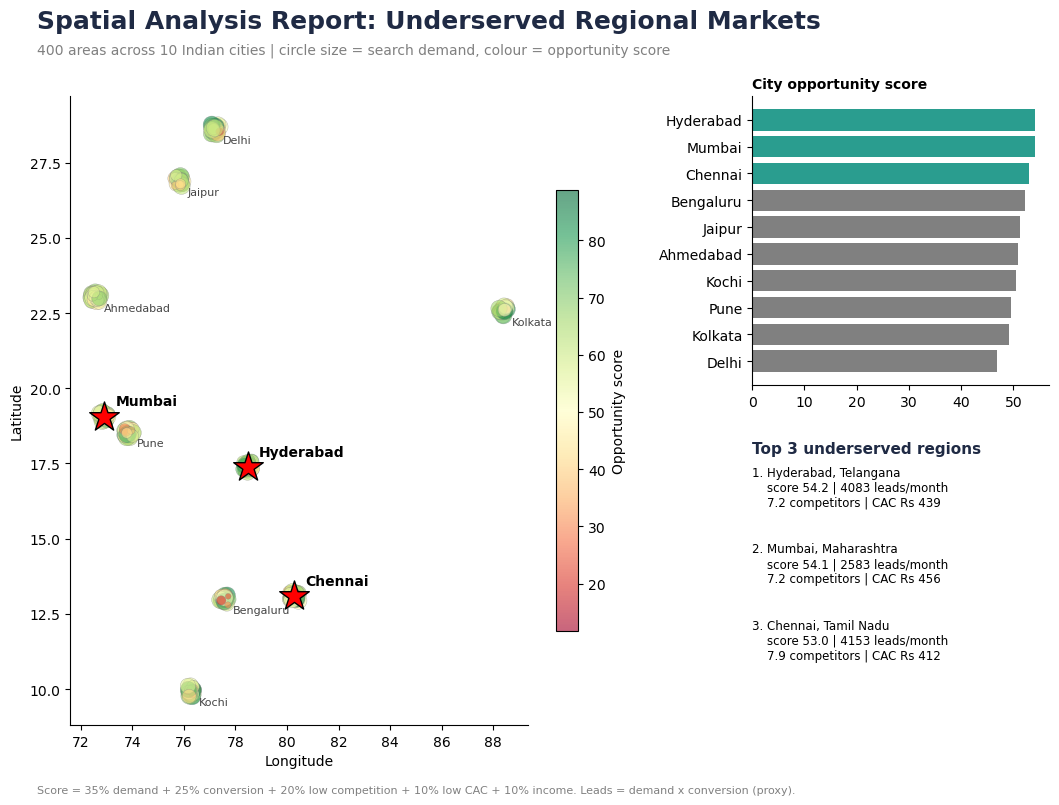

Saved report PDF


In [13]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

NAVY, TEAL = '#1f2a44', '#2a9d8f'
with PdfPages(r"C:\Users\Girish\Downloads\Spatial_Analysis_Report.pdf") as pdf:
    fig = plt.figure(figsize=(11, 8.5))
    fig.text(0.05, 0.94, 'Spatial Analysis Report: Underserved Regional Markets', fontsize=18, fontweight='bold', color=NAVY)
    fig.text(0.05, 0.91, '400 areas across 10 Indian cities | circle size = search demand, colour = opportunity score', fontsize=10, color='grey')

    # spatial scatter map
    ax = fig.add_axes([0.08, 0.12, 0.52, 0.74])
    sc = ax.scatter(df.Longitude, df.Latitude, s=df.MonthlySearchDemand/12, c=df.Score,
                    cmap='RdYlGn', alpha=0.6, edgecolor='grey', linewidth=0.3)
    for _, r in city.head(3).iterrows():
        ax.scatter(r.lon, r.lat, marker='*', s=500, color='red', edgecolor='black', zorder=5)
        ax.annotate(r.City, (r.lon, r.lat), xytext=(8, 8), textcoords='offset points', fontweight='bold')
    for _, r in city.iloc[3:].iterrows():
        ax.annotate(r.City, (r.lon, r.lat), xytext=(6, -10), textcoords='offset points', fontsize=8, color='#444')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.spines[['top', 'right']].set_visible(False)
    plt.colorbar(sc, ax=ax, label='Opportunity score', shrink=0.7)

    # city ranking bars
    ax2 = fig.add_axes([0.70, 0.52, 0.27, 0.34])
    c = city.sort_values('score')
    ax2.barh(c.City, c.score, color=[TEAL if i >= 7 else 'grey' for i in range(len(c))])
    ax2.set_title('City opportunity score', loc='left', fontweight='bold', fontsize=10)
    ax2.spines[['top', 'right']].set_visible(False)

    # top 3 text
    fig.text(0.70, 0.44, 'Top 3 underserved regions', fontsize=11, fontweight='bold', color=NAVY)
    for i, r in city.head(3).iterrows():
        fig.text(0.70, 0.425 - i*0.09,
                 f'{i+1}. {r.City}, {r.State}\n    score {r.score:.1f} | {r.leads:.0f} leads/month\n'
                 f'    {r.avg_competitors:.1f} competitors | CAC Rs {r.avg_cac:.0f}',
                 fontsize=8.5, va='top')

    fig.text(0.05, 0.04, 'Score = 35% demand + 25% conversion + 20% low competition + 10% low CAC + 10% income. '
             'Leads = demand x conversion (proxy).', fontsize=8, color='grey')
    pdf.savefig(fig)
    plt.show()
    plt.close(fig)
print('Saved report PDF')